# Model Analysis — Logistic Regression

This notebook develops and compares logistic regression models to predict customer response to a monthly food basket subscription campaign for a retail food company. Building on the EDA, which identified behavioural variables, particularly past campaign acceptance and recency, as the strongest predictors of response, the modelling strategy follows a structured diagnostic logic:

1. A **Full Model** trained on all engineered features to identify which predictors survive penalisation.
2. A **Behavioural Model** focusing on engagement and purchase history.
3. A **Demographic Model** focusing on customer profile and household composition.

Comparing these three models allows us to assess whether campaign response is better explained by *who the customer is* or *how the customer behaves*, and to select the most actionable model for deployment.

## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from scipy.stats import loguniform

import warnings
warnings.filterwarnings('ignore')

# Cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# OOF threshold tuning helper
def find_best_threshold_oof(pipeline, X_train, y_train, cv=5):
    oof_probs = cross_val_predict(
        pipeline, X_train, y_train, cv=cv, method="predict_proba"
    )[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"Optimal threshold (F1): {best_threshold:.4f}")
    print(f"Best OOF F1:            {best_f1:.4f}")

    return best_threshold

#Standardised evaluation helper
def evaluate_model(model, X_te, y_te, model_name, threshold=0.5):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model':     model_name,
        'Threshold': round(threshold, 4),
        'ROC-AUC':   round(roc_auc_score(y_te, y_prob), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1':        round(f1_score(y_te, y_pred, zero_division=0), 4),
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
    }

In [2]:
# Data loading
df = pd.read_csv('../data/marketing_campaign_clean.csv')

# Data overview
print(f"Dataset shape: {df.shape}")
print(f"\nClass balance:")
print(df['Response'].value_counts(normalize=True).round(3))
df.columns

Dataset shape: (2236, 30)

Class balance:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Income_missing', 'Customer_Tenure', 'Age',
       'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
       'Response'],
      dtype='object')

## 1. Feature Selection

The clean dataset already includes the engineered features from the EDA notebook
(`Total_Spending`, `Total_Purchases`, `Total_Accepted_Campaigns`, `Customer_Tenure`, `Age`).

The original columns (individual spend categories and individual campaign dummies) are
dropped here, as they have been combined into the aggregated features. `Income_missing` and
`Complain` are also dropped.

To enable clean model comparisons, three non-overlapping feature sets are constructed upfront and in the following section.

In [3]:
# Create copy of the dataframe for modeling
df_model = df.copy()

# Drop columns that won't be used in the model
cols_to_drop = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Income_missing', 'Complain'
]

df_model = df_model.drop(columns=cols_to_drop)


# Define features and target
target = 'Response'

## Full Model
numerical_features_full = [
    'Age', 'Income', 'Recency', 'Customer_Tenure',
    'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome'
]
categorical_features_full = ['Education', 'Marital_Status']

## Behavioural Model
numerical_features_behav = [
    'Recency', 'Total_Spending', 'Total_Purchases',
    'Total_Accepted_Campaigns', 'NumDealsPurchases', 'NumWebVisitsMonth'
]
categorical_features_behav = [] 

# Demographic Model
numerical_features_demo = [
    'Age', 'Income', 'Customer_Tenure',
    'Kidhome', 'Teenhome'
]
categorical_features_demo = ['Education', 'Marital_Status']


print(f"Full model: {len(numerical_features_full)} numerical + {len(categorical_features_full)} categorical")
print(f"Behavioural: {len(numerical_features_behav)} numerical + {len(categorical_features_behav)} categorical")
print(f"Demographic: {len(numerical_features_demo)} numerical + {len(categorical_features_demo)} categorical")

Full model: 11 numerical + 2 categorical
Behavioural: 6 numerical + 0 categorical
Demographic: 5 numerical + 2 categorical


In [4]:
X_full  = pd.concat([df_model[numerical_features_full],
                     pd.get_dummies(df_model[categorical_features_full],  drop_first=True)], axis=1)

X_behav = df_model[numerical_features_behav].copy()

X_demo  = pd.concat([df_model[numerical_features_demo],
                     pd.get_dummies(df_model[categorical_features_demo],  drop_first=True)], axis=1)

y = df_model[target].copy()

print(f"\nX_full  shape : {X_full.shape}")
print(f"X_behav shape : {X_behav.shape}")
print(f"X_demo  shape : {X_demo.shape}")
print(f"y       shape : {y.shape}  | Positive rate: {y.mean():.1%}")



X_full  shape : (2236, 20)
X_behav shape : (2236, 6)
X_demo  shape : (2236, 14)
y       shape : (2236,)  | Positive rate: 14.9%


## 2. Train/Test Split

The train and test indices were created once in the EDA notebook (Section 9) using a stratified 80/20 split with `random_state=42`, and saved to disk as `.npy` files.

Loading them here, rather than calling `train_test_split` again, guarantees that this notebook uses exactly the same observations as the advanced models developed in this project, making cross-model comparisons statistically valid.

In [6]:
X_all = df_model[numerical_features_full + categorical_features_full]

# Load the shared split indices produced in EDA.ipynb (Section 9)
idx_train = np.load('../data/idx_train.npy')
idx_test  = np.load('../data/idx_test.npy')

# Slice each feature matrix and the target using the shared indices
X_train_all = X_all.iloc[idx_train]
X_test_all  = X_all.iloc[idx_test]
y_train     = y.iloc[idx_train]
y_test      = y.iloc[idx_test]

X_train_full  = X_train_all[numerical_features_full + categorical_features_full]
X_test_full   = X_test_all[numerical_features_full + categorical_features_full]

X_train_behav = X_train_all[numerical_features_behav]
X_test_behav  = X_test_all[numerical_features_behav]

X_train_demo  = X_train_all[numerical_features_demo]
X_test_demo   = X_test_all[numerical_features_demo]

print(f'Train size: {len(y_train):,}  (positives: {y_train.sum()})')
print(f'Test size:  {len(y_test):,}   (positives: {y_test.sum()})')
print(f'Train positive rate: {y_train.mean():.1%}')
print(f'Test  positive rate: {y_test.mean():.1%}')


Train size: 1,788  (positives: 267)
Test size:  448   (positives: 67)
Train positive rate: 14.9%
Test  positive rate: 15.0%


## 3. Full Model - Elastic Net Regularization

The full model employs **Elastic Net** regularisation, which combines L1  and L2 penalties in a weighted sum governed by `l1_ratio`. The choice of  Elastic Net over pure L1 or L2 is validated empirically in Section 3.2 through a cross-validated comparison of all regularisation strategies at a fixed `C=1.0`.

### 3.1. Baseline Model (No Tuning)

Before making any modelling decisions, a baseline Logistic Regression model is trained using scikit-learn’s default configuration (C=1.0, lbfgs solver). Under this setup, L2 regularization is applied by default, but no explicit tuning of the regularization type, strength, or class imbalance handling is performed. 

This model serves as a reference point against which subsequent improvements (such as the introduction of Elastic Net regularization and hyperparameter optimization) are evaluated in terms of ROC-AUC.

In [7]:
# Helper to create a fresh preprocessor for each model (to avoid data leakage from fitting on the full training set)
def make_preprocessor_full():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features_full),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features_full)
    ])

# Baseline with sklearn defaults (L2, C=1.0, lbfgs)
full_model_base = Pipeline(steps=[
    ('preprocessor', make_preprocessor_full()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

full_model_base.fit(X_train_full, y_train)

y_prob_base = full_model_base.predict_proba(X_test_full)[:, 1]
y_pred_base = full_model_base.predict(X_test_full)

print(f"Default LR — ROC-AUC   : {roc_auc_score(y_test, y_prob_base):.4f}")
print(f"Default LR — Recall    : {recall_score(y_test, y_pred_base):.4f}")
print(f"Default LR — F1        : {f1_score(y_test, y_pred_base):.4f}")

Default LR — ROC-AUC   : 0.8790
Default LR — Recall    : 0.7612
Default LR — F1        : 0.5312


### 3.2. Regularization Strategy Selection

Four penalty options are compared at the default `C=1.0` using 5-fold stratified cross-validation, before any tuning is performed. This ensures 
the penalty choice is data-driven rather than assumed upfront.

In [47]:
# Compare regularisation strategies
from sklearn.model_selection import cross_val_score

reg_configs = [
    {
        'name':    'No Regularisation',
        'penalty': None,
        'solver':  'lbfgs',
        'C':       1.0,      
        'l1_ratio': None,
    },
    {
        'name':    'L2 (Ridge)',
        'penalty': 'l2',
        'solver':  'lbfgs',
        'C':       1.0,
        'l1_ratio': None,
    },
    {
        'name':    'L1 (Lasso)',
        'penalty': 'l1',
        'solver':  'saga',
        'C':       1.0,
        'l1_ratio': None,
    },
    {
        'name':    'Elastic Net',
        'penalty': 'elasticnet',
        'solver':  'saga',
        'C':       1.0,
        'l1_ratio': 0.5,
    },
]

reg_results = []
for cfg in reg_configs:
    lr_kwargs = dict(
        penalty=cfg['penalty'],
        solver=cfg['solver'],
        C=cfg['C'],
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    if cfg['l1_ratio'] is not None:
        lr_kwargs['l1_ratio'] = cfg['l1_ratio']

    pipe = Pipeline(steps=[
        ('preprocessor', make_preprocessor_full()),
        ('classifier',   LogisticRegression(**lr_kwargs))
    ])

    scores = cross_val_score(
        pipe, X_train_full, y_train,
        cv=cv_strategy, scoring='roc_auc'
    )
    reg_results.append({
        'Regularisation': cfg['name'],
        'CV AUC Mean':    round(scores.mean(), 4),
        'CV AUC Std':     round(scores.std(), 4),
    })

reg_df = pd.DataFrame(reg_results).set_index('Regularisation')
print("Regularisation Strategy Comparison (C=1.0, untuned)\n")
print(reg_df.to_string())

Regularisation Strategy Comparison (C=1.0, untuned)

                   CV AUC Mean  CV AUC Std
Regularisation                            
No Regularisation       0.8816      0.0150
L2 (Ridge)              0.8881      0.0207
L1 (Lasso)              0.8880      0.0209
Elastic Net             0.8882      0.0207


The results show that all three regularised penalties perform similarly (CV AUC between 0.888 and 0.889), while no regularisation is the weakest 
option (0.882), confirming that some form of penalisation is necessary. **Elastic Net** achieves the highest mean CV AUC (0.8882) and is selected going forward.

### 3.3 Hyperparameter Tuning (RandomizedSearchCV + GridSearchCV)


Tuning follows three stages. First, **RandomizedSearchCV** samples 30 random combinations of `C` and `l1_ratio` over a broad search space to identify a promising region. 

Second and third, two rounds of **GridSearchCV** progressively narrow the search around the best `C` found so far, while keeping `l1_ratio` fixed at the value selected in Stage 1. 

All three stages use **StratifiedKFold** with 5 folds to preserve the 15% positive rate in each fold, and **ROC-AUC** as the scoring metric to evaluate ranking ability independently of any threshold.

In [48]:
# RandomizedSearchCV
param_dist = {
    'classifier__C':        loguniform(1e-3, 10),
    'classifier__l1_ratio': [0.1, 0.2, 0.3, 0.5, 0.7, 0.9],
}

rand_search = RandomizedSearchCV(
    estimator = Pipeline(steps=[
        ('preprocessor', make_preprocessor_full()),
        ('classifier', LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_distributions = param_dist,
    n_iter       = 30,
    cv           = cv_strategy,
    scoring      = 'roc_auc',
    random_state = 42,
    n_jobs       = 1,
    verbose      = 1
)
rand_search.fit(X_train_full, y_train)

print(f"Stage 1 — Best parameters : {rand_search.best_params_}")
print(f"Stage 1 — Best CV AUC     : {rand_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Stage 1 — Best parameters : {'classifier__C': np.float64(0.7726718477963437), 'classifier__l1_ratio': 0.9}
Stage 1 — Best CV AUC     : 0.8880


In [50]:
# Tighten around best params from Stage 1
best_C  = rand_search.best_params_['classifier__C']
best_l1 = rand_search.best_params_['classifier__l1_ratio']

lr_grid_r1 = {
    'classifier__C':        [best_C * 0.25, best_C * 0.5, best_C, best_C * 2, best_C * 4],
    'classifier__l1_ratio': [best_l1],
}

lr_grid_search_r1 = GridSearchCV(
    Pipeline(steps=[
        ('preprocessor', make_preprocessor_full()),
        ('classifier', LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_grid = lr_grid_r1,
    scoring    = 'roc_auc',
    cv         = cv_strategy,
    n_jobs     = 1,
    verbose    = 1
)
lr_grid_search_r1.fit(X_train_full, y_train)

print(f"Stage 2 — Best parameters : {lr_grid_search_r1.best_params_}")
print(f"Stage 2 — Best CV AUC     : {lr_grid_search_r1.best_score_:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Stage 2 — Best parameters : {'classifier__C': np.float64(1.5453436955926874), 'classifier__l1_ratio': 0.9}
Stage 2 — Best CV AUC     : 0.8881


In [51]:
best_C_r2 = lr_grid_search_r1.best_params_['classifier__C']

lr_grid_r2 = {
    'classifier__C':        [best_C_r2 * 0.7, best_C_r2, best_C_r2 * 1.3],
    'classifier__l1_ratio': [best_l1],
}

lr_grid_search_r2 = GridSearchCV(
    Pipeline(steps=[
        ('preprocessor', make_preprocessor_full()),
        ('classifier', LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_grid = lr_grid_r2,
    scoring    = 'roc_auc',
    cv         = cv_strategy,
    n_jobs     = 1,
    verbose    = 1
)
lr_grid_search_r2.fit(X_train_full, y_train)

print(f"Stage 3 — Best parameters : {lr_grid_search_r2.best_params_}")
print(f"Stage 3 — Best CV AUC     : {lr_grid_search_r2.best_score_:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Stage 3 — Best parameters : {'classifier__C': np.float64(1.5453436955926874), 'classifier__l1_ratio': 0.9}
Stage 3 — Best CV AUC     : 0.8881


### 3.4 Tuning Progression & Best Parameter Selection

Three rounds of search progressively narrowed the parameter space. The table and chart below compare all rounds and the best parameters (highest CV AUC) are then used to rebuild `full_model` for all subsequent evaluation.

Hyperparameter Tuning Progression — Logistic Regression (Full Model)
                                          C  l1_ratio  CV AUC
Round                                                        
Stage 1\nRandomizedSearch (30 iter)  0.7727       0.9  0.8880
Stage 2\nGridSearch (5 candidates)   1.5453       0.9  0.8881
Stage 3\nGridSearch (3 candidates)   1.5453       0.9  0.8881


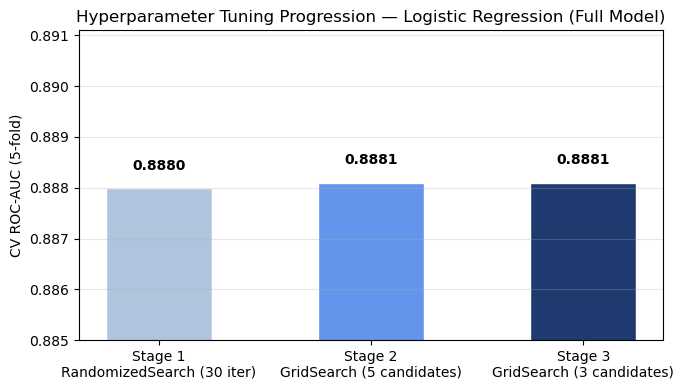

In [54]:
tuning_summary = [
    {
        'Round':    'Stage 1\nRandomizedSearch (30 iter)',
        'C':        round(rand_search.best_params_['classifier__C'], 4),
        'l1_ratio': rand_search.best_params_['classifier__l1_ratio'],
        'CV AUC':   round(rand_search.best_score_, 4),
    },
    {
        'Round':    'Stage 2\nGridSearch (5 candidates)',
        'C':        round(lr_grid_search_r1.best_params_['classifier__C'], 4),
        'l1_ratio': lr_grid_search_r1.best_params_['classifier__l1_ratio'],
        'CV AUC':   round(lr_grid_search_r1.best_score_, 4),
    },
    {
        'Round':    'Stage 3\nGridSearch (3 candidates)',
        'C':        round(lr_grid_search_r2.best_params_['classifier__C'], 4),
        'l1_ratio': lr_grid_search_r2.best_params_['classifier__l1_ratio'],
        'CV AUC':   round(lr_grid_search_r2.best_score_, 4),
    },
]

tuning_df = pd.DataFrame(tuning_summary).set_index('Round')
print("Hyperparameter Tuning Progression — Logistic Regression (Full Model)")
print(tuning_df.to_string())

# Bar chart: CV AUC progression
aucs   = [r['CV AUC'] for r in tuning_summary]
labels = [r['Round']  for r in tuning_summary]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, aucs, color=['#b0c4de', '#6495ed', '#1e3a6e'],
              edgecolor='white', width=0.5)
ax.set_ylim(min(aucs) - 0.003, max(aucs) + 0.003)
ax.set_ylabel("CV ROC-AUC (5-fold)")
ax.set_title("Hyperparameter Tuning Progression — Logistic Regression (Full Model)")
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
            f"{auc:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The optimal `l1_ratio` of 0.9 indicates that the penalty leans heavily toward L1, meaning the model prefers aggressive feature selection over coefficient shrinkage. 

In [53]:
# Rebuild full_model with best parameters
best_C_final  = lr_grid_search_r2.best_params_['classifier__C']
best_l1_final = lr_grid_search_r2.best_params_['classifier__l1_ratio']

print(f"Final best parameters (Stage 3): C={best_C_final:.4f}, l1_ratio={best_l1_final}")
print(f"Best CV AUC : {lr_grid_search_r2.best_score_:.4f}")

full_model = Pipeline(steps=[
    ('preprocessor', make_preprocessor_full()),
    ('classifier', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=best_C_final,
        l1_ratio=best_l1_final,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])
full_model.fit(X_train_full, y_train)
print("full_model rebuilt with optimised parameters.")

# CV score on training set
cv_scores = cross_val_score(
    full_model, X_train_full, y_train,
    cv=cv_strategy, scoring='roc_auc'
)
print(f"\nCV ROC-AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Improvement over baseline
baseline_cv = cross_val_score(
    full_model_base, X_train_full, y_train,
    cv=cv_strategy, scoring='roc_auc'
).mean()
tuned_cv = cv_scores.mean()
print(f"\nBaseline CV AUC : {baseline_cv:.4f}")
print(f"Tuned CV AUC    : {tuned_cv:.4f}  (Δ = {tuned_cv - baseline_cv:+.4f})")

Final best parameters (Stage 3): C=1.5453, l1_ratio=0.9
Best CV AUC : 0.8881
full_model rebuilt with optimised parameters.

CV ROC-AUC : 0.8881 ± 0.0205

Baseline CV AUC : 0.8881
Tuned CV AUC    : 0.8881  (Δ = -0.0000)


In [38]:
# Compare pure L1 vs Elastic Net at the tuned parameters
l1_model = Pipeline(steps=[
    ('preprocessor', make_preprocessor_full()),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='saga',
        C=best_C_final,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

cv_l1 = cross_val_score(
    l1_model, X_train_full, y_train,
    cv=cv_strategy, scoring='roc_auc'
).mean()

print(f"Elastic Net (l1_ratio=0.9) CV AUC : {tuned_cv:.4f}")
print(f"Pure L1                   CV AUC : {cv_l1:.4f}")
print(f"Difference                        : {tuned_cv - cv_l1:+.4f}")

Elastic Net (l1_ratio=0.9) CV AUC : 0.8881
Pure L1                   CV AUC : 0.8881
Difference                        : -0.0000


### 3.5 Threshold Tuning

By default, scikit-learn classifiers predict a positive class whenever the predicted probability exceeds 0.5, which is rarely optimal under class imbalance. 

In a marketing campaign context, the choice of threshold has direct business consequences: too low and the company wastes resources contacting customers who will not convert, and too high and genuine prospects are missed entirely. 

To find the cutoff that best balances these two costs, we evaluate the F1 score across all possible thresholds using out-of-fold cross-validation probabilities on the training set, ensuring no test data influences the selection. 

**F1** is the appropriate criteria here as it only scores high when both precision and recall are strong, rewarding a threshold that maximises correctly identified responders without generating a disproportionate number of wasted contacts. The resulting optimal threshold replaces the default 0.5 and is applied to the test set for final evaluation.

In [55]:
threshold_full = find_best_threshold_oof(full_model, X_train_full, y_train)

Optimal threshold (F1): 0.6282
Best OOF F1:            0.5778


### 3.6. Model Evaluation

The tuned model is evaluated on the held-out test set using the OOF-selected threshold. 

In [57]:
y_prob_full = full_model.predict_proba(X_test_full)[:, 1]
y_pred_full = (y_prob_full >= threshold_full).astype(int)

print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_full):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_full):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_full):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_full):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_full):.4f}")

ROC-AUC   : 0.8790
Precision : 0.5109
Recall    : 0.7015
F1        : 0.5912
Accuracy  : 0.8549


### 3.7. Confusion Matrix

We developed a confusion matrix to show how the model’s predictions compare to the actual campaign responses. 

This is important because, for example, predicting that a customer will respond when they do not 
may lead to unnecessary campaign costs, while predicting that a customer will not respond when 
they actually would means missing a potential opportunity.

The confusion matrix therefore helps evaluate whether the model is better at identifying 
responders or non-responders.

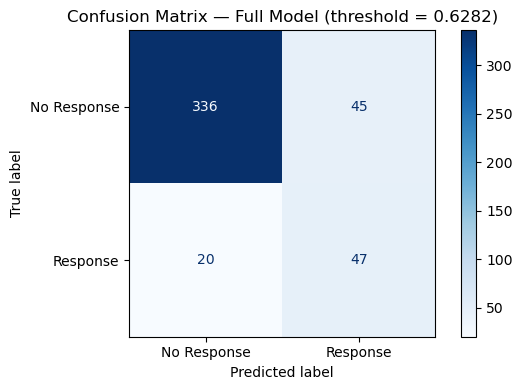

              precision    recall  f1-score   support

 No Response       0.94      0.88      0.91       381
    Response       0.51      0.70      0.59        67

    accuracy                           0.85       448
   macro avg       0.73      0.79      0.75       448
weighted avg       0.88      0.85      0.86       448



In [61]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_full,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — Full Model (threshold = {threshold_full:.4f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_full,
                             target_names=['No Response', 'Response']))

### 3.8. Precision-Recall Curve

The Precision-Recall curve illustrates the trade-off across all possible thresholds without fixing one upfront. The vertical line marks the selected operating threshold.

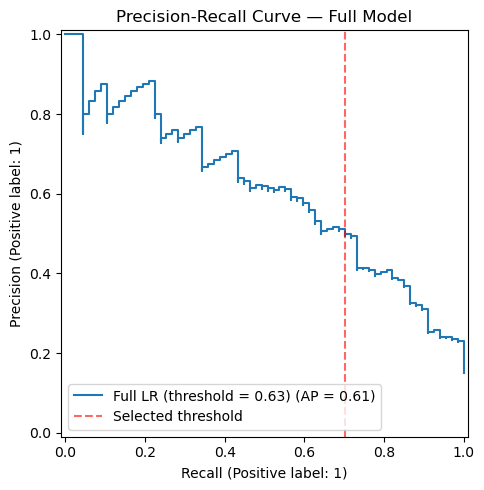

In [62]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_full,
    name=f"Full LR (threshold = {threshold_full:.2f})",
    ax=ax
)
ax.axvline(recall_score(y_test, y_pred_full), color='red',
           linestyle='--', alpha=0.6, label='Selected threshold')
ax.set_title("Precision-Recall Curve — Full Model")
ax.legend()
plt.tight_layout()
plt.show()

### 3.9. ROC Curve

The ROC curve measures the model's ability to rank customers by their likelihood of responding, across all possible thresholds. The AUC summarises this into a single number: the probability that a randomly chosen responder is ranked higher
than a randomly chosen non-responder.

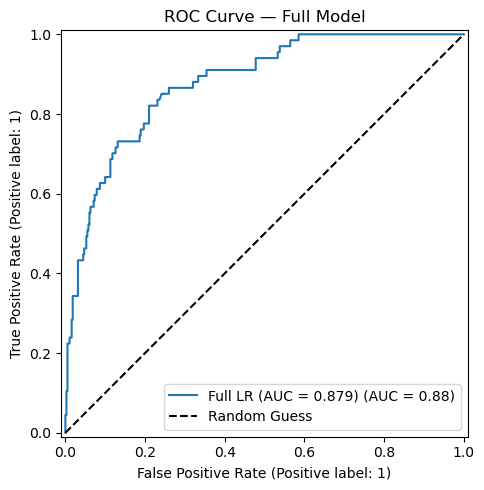

In [65]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_full,
    name=f"Full LR (AUC = {roc_auc_score(y_test, y_prob_full):.3f})",
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax.set_title("ROC Curve — Full Model")
ax.legend()
plt.tight_layout()
plt.show()

### 3.10. Learning Curves

Learning curves show how model performance changes as the amount of training data increases. They allow us to assess whether the model is suffering from **overfitting or underfitting**, and whether additional training data could improve performance.

- If the training score is much higher than the validation score, the model may be **overfitting**.
- If both scores are low, the model may be **underfitting**.

/Applications/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Applications/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Applications/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Applications/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Applications/anaconda3/lib/python3.13/site-packages/sklearn

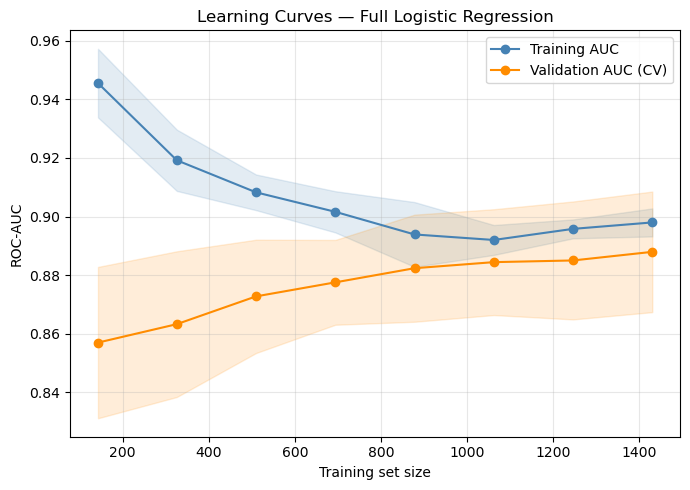

In [67]:
train_sizes, train_scores, val_scores = learning_curve(
    full_model, X_train_full, y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(train_sizes, train_mean - train_std,
                train_mean + train_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation AUC (CV)')
ax.fill_between(train_sizes, val_mean - val_std,
                val_mean + val_std, alpha=0.15, color='darkorange')
ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curves — Full Logistic Regression")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.11. Feature Importance (Coefficients)
Logistic regression coefficients represent the change in log-odds of responding for a one-unit increase in a standardised feature, holding all others constant. 
Exponentiated as odds ratios, they quantify the multiplicative change in the odds of response. Features zeroed out by the L1 component of Elastic Net are excluded from the plot.

In [68]:
ohe_full = full_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names_full = ohe_full.get_feature_names_out(categorical_features_full).tolist()
all_names_full = numerical_features_full + cat_names_full

coefs_full = full_model.named_steps['classifier'].coef_[0]

coef_df_full = pd.DataFrame({
    'Feature': all_names_full,
    'Coefficient': coefs_full,
    'Odds Ratio': np.exp(coefs_full)
}).sort_values(by='Coefficient', ascending=False)

n_zeroed = (coef_df_full['Coefficient'] == 0).sum()
print(f"Features retained by L1 : {len(coef_df_full) - n_zeroed} / {len(coef_df_full)}")
print(f"Features zeroed out: {n_zeroed}\n")

coef_df_full.round(4)

Features retained by L1 : 19 / 20
Features zeroed out: 1



,Feature,Coefficient,Odds Ratio
6,Total_Accepted_Campaigns,1.1103,3.0354
3,Customer_Tenure,0.9919,2.6964
14,Education_PhD,0.9917,2.6959
4,Total_Spending,0.4570,1.5793
7,NumDealsPurchases,0.2990,1.3485
19,Marital_Status_Widow,0.2862,1.3313
13,Education_Master,0.1968,1.2175
8,NumWebVisitsMonth,0.1911,1.2106
1,Income,0.1832,1.2011
9,Kidhome,0.1802,1.1975


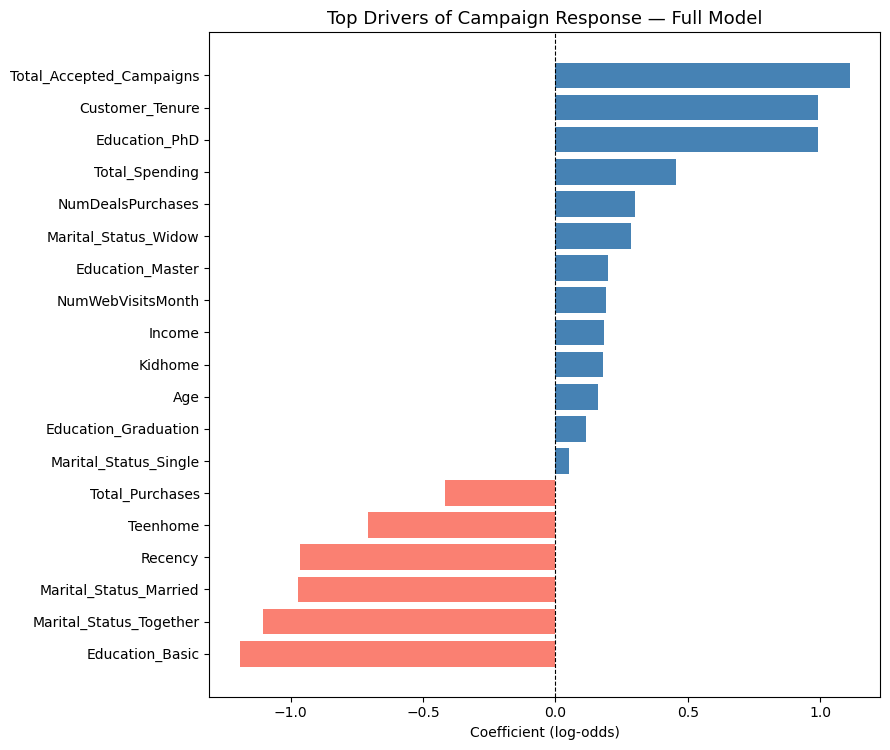

In [70]:
coef_df_full_nonzero = coef_df_full[coef_df_full['Coefficient'] != 0].copy()
coef_df_full_nonzero = coef_df_full_nonzero.sort_values('Coefficient', ascending=True)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_full_nonzero['Coefficient']]
fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_full_nonzero) * 0.4)))
ax.barh(coef_df_full_nonzero['Feature'], coef_df_full_nonzero['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Full Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

### 3.12. Permutation Importance

To obtain a more robust measure of feature importance, we compute permutation importance on the test set. This method evaluates the contribution of each feature by randomly shuffling its values and measuring the resulting drop in model performance.

If shuffling a feature leads to a large decrease in ROC-AUC, it indicates that the feature plays an important role in the model’s predictions.

Permutation Importance — Full Model (test set):

                 Feature  Importance_Mean  Importance_Std
Total_Accepted_Campaigns         0.115940        0.011817
                 Recency         0.072886        0.006347
         Customer_Tenure         0.044956        0.014779
          Marital_Status         0.030425        0.005214
          Total_Spending         0.026760        0.006287
                Teenhome         0.023602        0.013806
               Education         0.016389        0.003994
       NumDealsPurchases         0.014520        0.004036
                  Income         0.005277        0.002769
       NumWebVisitsMonth         0.002969        0.003399
                     Age         0.002068        0.002362
                 Kidhome         0.000991        0.002433
         Total_Purchases        -0.001487        0.006441


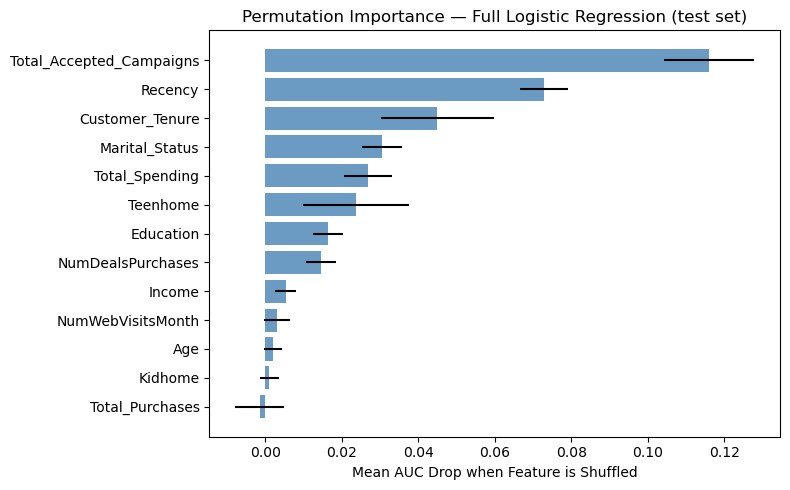

In [75]:
raw_feature_names = numerical_features_full + categorical_features_full

perm_result = permutation_importance(
    full_model, X_test_full, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature':         raw_feature_names,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std':  perm_result.importances_std,
}).sort_values('Importance_Mean', ascending=False)

print("Permutation Importance — Full Model (test set):\n")
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
top_perm = perm_df.sort_values('Importance_Mean')
ax.barh(top_perm['Feature'], top_perm['Importance_Mean'],
        xerr=top_perm['Importance_Std'], color='steelblue', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Full Logistic Regression (test set)")
plt.tight_layout()
plt.show()

### 3.13. SHAP Values

To further interpret the model, we compute SHAP (SHapley Additive exPlanations) values. SHAP quantifies how each feature contributes to the model’s prediction by measuring how much it increases or decreases the predicted probability relative to a baseline.

`LinearExplainer` is used here as it is the appropriate and efficient SHAP method for logistic regression.

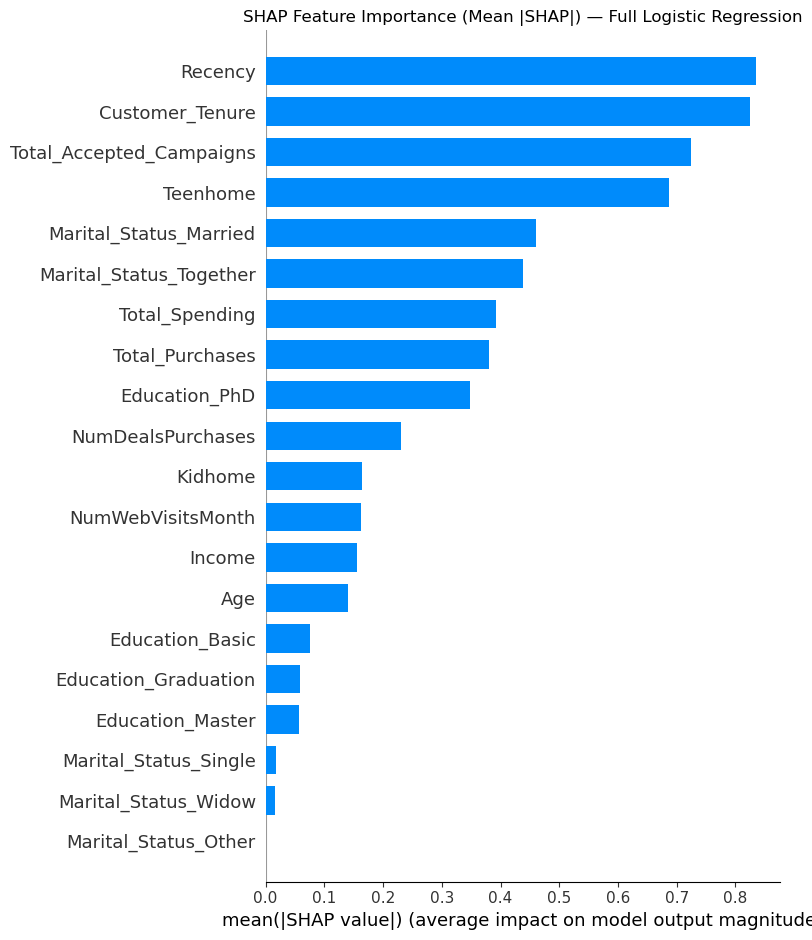

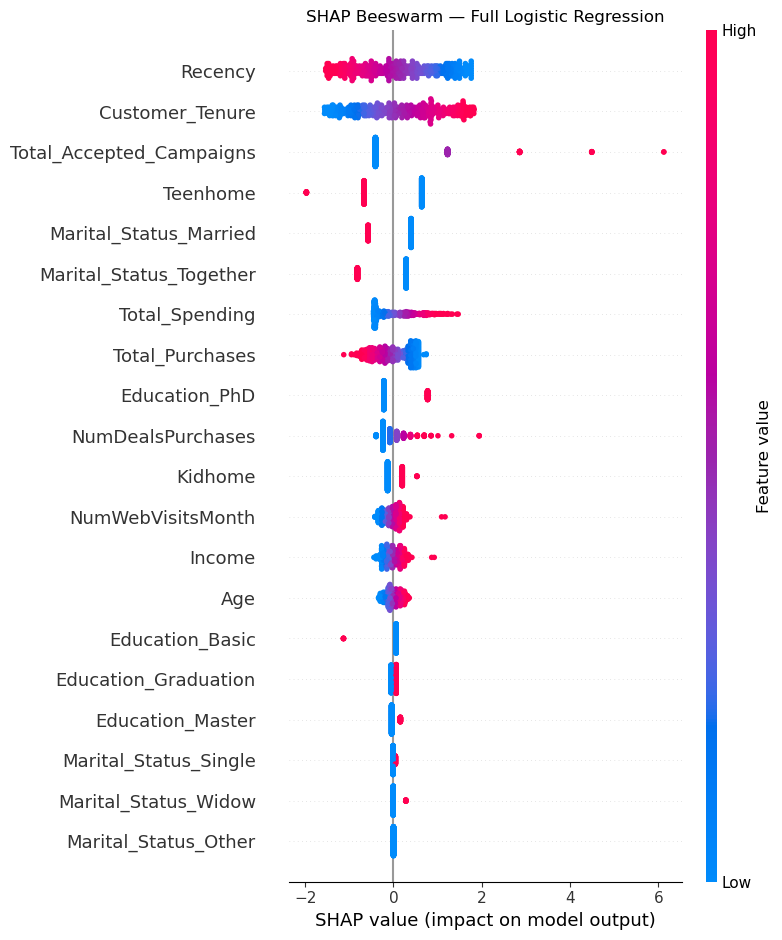

In [76]:
X_test_transformed  = full_model.named_steps['preprocessor'].transform(X_test_full)
X_train_transformed = full_model.named_steps['preprocessor'].transform(X_train_full)

explainer   = shap.LinearExplainer(
    full_model.named_steps['classifier'],
    X_train_transformed,
    feature_perturbation='interventional'
)
shap_values = explainer.shap_values(X_test_transformed)

# Global summary: bar chart
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_names_full,
                  plot_type='bar', show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) — Full Logistic Regression")
plt.tight_layout()
plt.show()

# Global beeswarm: direction + magnitude
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_names_full, show=False)
plt.title("SHAP Beeswarm — Full Logistic Regression")
plt.tight_layout()
plt.show()

### 3.14. Interpretation of Full Model Results

The full logistic regression model provides a general view of which factors influence campaign response. It uses Elastic Net regularisation with an optimal l1_ratio of 0.3, indicating that the best penalty leans closer to L2 than L1.

he model achieves a **ROC-AUC** of 0.88 and an **F1** of 0.58 on the positive class, with the tuned threshold of 0.33 correctly identifying 39 out of 67 actual responders (**recall** of 58%) while maintaining a **precision** of 57% (meaning that roughly 1 in 2 customers flagged as likely responders would actually convert), a substantial improvement over the 15% baseline.

Amongst the positive indicators, past campaign acceptance is the best predictor (OR = 2.95), followed by `Customer_Tenure` (OR = 2.47) and `Education_PhD` (OR = 2.38), indicating that committed, highly educated consumers with a history of involvement in campaigns are the most responsive. `Total_Spending` (OR = 1.29), `Income` (OR = 1.25), and `Education_Master` (OR = 1.26) all indicate that higher-value, better educated clients react more frequently.

On the contrary, `Marital_Status_Together` (OR = 0.33) and `Marital_Status_Married` (OR = 0.35) are the most powerful deterring factors, followed by `recency` (OR = 0.41) and `Education_Basic` (OR = 0.45), which indicates that recently inactive customers in shared households with lower levels of education are significantly less likely to respond. `Teenhome` (OR = 0.51) and `Total_Purchases` (OR = 0.71) both lower response probability.

Only `Marital_Status_Other` was zeroed out by the Elastic Net penalty, confirming that the L2 component successfully retained most features rather than eliminating correlated ones arbitrarily as pure L1 would have done.

To isolate the contribution of behavioural and demographic signals separately, two targeted sub-models are estimated in the sections that follow, allowing us to evaluate whether campaign response is better explained by who the customer is or by how the customer behaves.

## 4. Behavioural Model - No Regularization

To better understand the role of customer engagement and purchasing behaviour in campaign response, we estimate a logistic regression model using only behavioural variables.

The behavioural model is estimated **without regularisation**. Total_Accepted_Campaigns, Recency, and Total_Spending were among the highest correlates with Response in the bivariate analysis, meaning that feature selection is not a modelling concern. With approximately 1,800 training observations and only six predictors, the observations-to-features ratio is large enough to make overfitting unlikely. 

In [77]:
# Helper: fresh preprocessor for behavioural model
def make_preprocessor_behav():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features_behav)
    ])

Exception ignored in: <function ResourceTracker.__del__ at 0x10d57f2e0>
Traceback (most recent call last):
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10edef2e0>
Traceback (most recent call last):
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__

### 4.1. Baseline Model

In [114]:
# Baseline: sklearn defaults (L2, C=1.0) with class_weight='balanced'
behav_model_base = Pipeline(steps=[
    ('preprocessor', make_preprocessor_behav()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

behav_model_base.fit(X_train_behav, y_train)

y_prob_behav_base = behav_model_base.predict_proba(X_test_behav)[:, 1]
y_pred_behav_base = behav_model_base.predict(X_test_behav)

print(f"Default LR — ROC-AUC : {roc_auc_score(y_test, y_prob_behav_base):.4f}")
print(f"Default LR — Recall  : {recall_score(y_test, y_pred_behav_base):.4f}")
print(f"Default LR — F1      : {f1_score(y_test, y_pred_behav_base):.4f}")

Default LR — ROC-AUC : 0.8590
Default LR — Recall  : 0.7313
Default LR — F1      : 0.5052


### 4.2 Regularisation Strategy Selection


In [116]:
reg_results_behav = []
for cfg in reg_configs:
    lr_kwargs = dict(
        penalty=cfg['penalty'],
        solver=cfg['solver'],
        C=cfg['C'],
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    if cfg['l1_ratio'] is not None:
        lr_kwargs['l1_ratio'] = cfg['l1_ratio']

    pipe = Pipeline(steps=[
        ('preprocessor', make_preprocessor_behav()),
        ('classifier',   LogisticRegression(**lr_kwargs))
    ])

    scores = cross_val_score(
        pipe, X_train_behav, y_train,
        cv=cv_strategy, scoring='roc_auc'
    )
    reg_results_behav.append({
        'Regularisation': cfg['name'],
        'CV AUC Mean':    round(scores.mean(), 4),
        'CV AUC Std':     round(scores.std(), 4),
    })

reg_df_behav = pd.DataFrame(reg_results_behav).set_index('Regularisation')
print("Regularisation Strategy Comparison — Behavioural Model (C=1.0, untuned)\n")
print(reg_df_behav.to_string())

Regularisation Strategy Comparison — Behavioural Model (C=1.0, untuned)

                   CV AUC Mean  CV AUC Std
Regularisation                            
No Regularisation       0.8334      0.0270
L2 (Ridge)              0.8333      0.0271
L1 (Lasso)              0.8330      0.0270
Elastic Net             0.8331      0.0269


Exception ignored in: <function ResourceTracker.__del__ at 0x10ee7f2e0>
Traceback (most recent call last):
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x110bfb2e0>
Traceback (most recent call last):
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__

### 4.3 Preprocessing & Behavioural Logistic Regression

The regularisation comparison in Section 4.2 shows that all four penalty options perform identically (CV AUC range: 0.8330–0.8334), confirming that regularisation adds no value for this feature set. 

`penalty=None` is therefore used. No hyperparameter tuning is performed since there are no regularisation parameters to optimise.

In [117]:
# Behavioural Logistic Regression — No Regularisation
behav_model = Pipeline(steps=[
    ('preprocessor', make_preprocessor_behav()),
    ('classifier', LogisticRegression(
        penalty=None,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

behav_model.fit(X_train_behav, y_train)

# CV score on training set
cv_scores_behav = cross_val_score(
    behav_model, X_train_behav, y_train,
    cv=cv_strategy, scoring='roc_auc'
)
print(f"CV ROC-AUC : {cv_scores_behav.mean():.4f} ± {cv_scores_behav.std():.4f}")

# Improvement over baseline
baseline_cv_behav = cross_val_score(
    behav_model_base, X_train_behav, y_train,
    cv=cv_strategy, scoring='roc_auc'
).mean()

print(f"\nBaseline CV AUC : {baseline_cv_behav:.4f}")
print(f"No-reg CV AUC   : {cv_scores_behav.mean():.4f}  "
      f"(Δ = {cv_scores_behav.mean() - baseline_cv_behav:+.4f})")

CV ROC-AUC : 0.8334 ± 0.0270

Baseline CV AUC : 0.8333
No-reg CV AUC   : 0.8334  (Δ = +0.0001)


### 4.2. Threshold Tuning

The optimal threshold is selected by maximising F1 across all possible cutoffs using out-of-fold cross-validation probabilities on the training set only, ensuring no test data influences the selection.

In [81]:
threshold_behav = find_best_threshold_oof(behav_model, X_train_behav, y_train)

Optimal threshold (F1): 0.6148
Best OOF F1:            0.5268


### 4.3. Model Evaluation

In [83]:
## Predictions and evaluation on test set
y_prob_behav = behav_model.predict_proba(X_test_behav)[:,1]
y_pred_behav = (y_prob_behav >= threshold_behav).astype(int)

print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_full):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_full):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_full):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_full):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_full):.4f}")

ROC-AUC   : 0.8790
Precision : 0.5109
Recall    : 0.7015
F1        : 0.5912
Accuracy  : 0.8549


### 4.4 Confusion Matrix

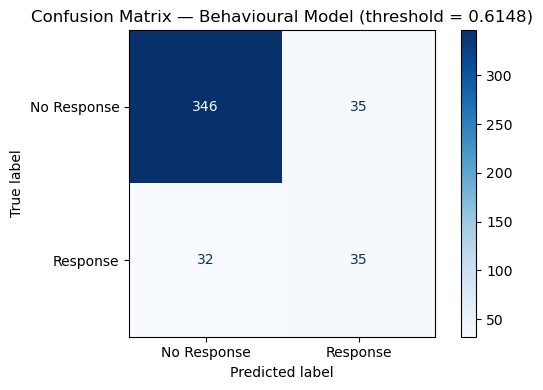

              precision    recall  f1-score   support

 No Response       0.92      0.91      0.91       381
    Response       0.50      0.52      0.51        67

    accuracy                           0.85       448
   macro avg       0.71      0.72      0.71       448
weighted avg       0.85      0.85      0.85       448



In [84]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_behav,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — Behavioural Model (threshold = {threshold_behav:.4f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_behav,
                             target_names=['No Response', 'Response']))

### 4.5. Precision-Recall Curve

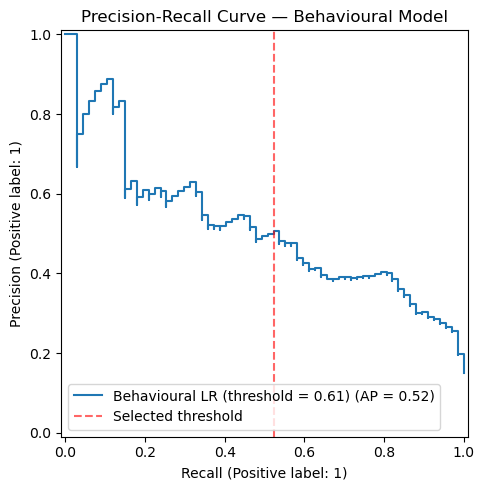

In [85]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_behav,
    name=f"Behavioural LR (threshold = {threshold_behav:.2f})",
    ax=ax
)
ax.axvline(recall_score(y_test, y_pred_behav), color='red',
           linestyle='--', alpha=0.6, label='Selected threshold')
ax.set_title("Precision-Recall Curve — Behavioural Model")
ax.legend()
plt.tight_layout()
plt.show()

### 4.6 ROC Curve

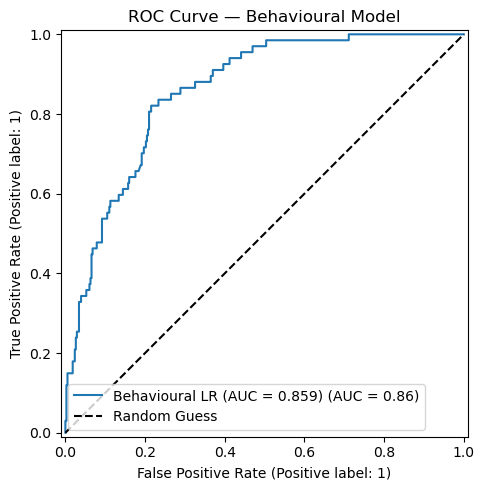

In [86]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_behav,
    name=f"Behavioural LR (AUC = {roc_auc_score(y_test, y_prob_behav):.3f})",
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title("ROC Curve — Behavioural Model")
ax.legend()
plt.tight_layout()
plt.show()

### 4.7. Feature Importance (Coefficients)

In [87]:
coefs_behav = behav_model.named_steps['classifier'].coef_[0]

coef_df_behav = pd.DataFrame({
    'Feature':     numerical_features_behav,
    'Coefficient': coefs_behav,
    'Odds Ratio':  np.exp(coefs_behav)
}).sort_values('Coefficient', ascending=False)

coef_df_behav.round(4)

,Feature,Coefficient,Odds Ratio
1,Total_Spending,0.9916,2.6955
3,Total_Accepted_Campaigns,0.8397,2.3156
5,NumWebVisitsMonth,0.5869,1.7984
4,NumDealsPurchases,0.1009,1.1062
2,Total_Purchases,-0.3803,0.6836
0,Recency,-0.7260,0.4839


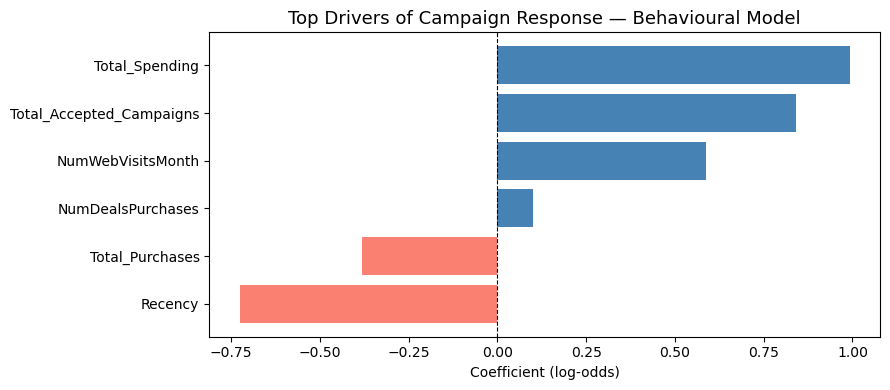

In [88]:
coef_df_behav_sorted = coef_df_behav.sort_values('Coefficient', ascending=True)
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_behav_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_behav_sorted) * 0.4)))
ax.barh(coef_df_behav_sorted['Feature'], coef_df_behav_sorted['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Behavioural Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

### 4.8. Permutation Importance

Permutation Importance — Behavioural Model (test set):

                 Feature  Importance_Mean  Importance_Std
          Total_Spending         0.177060        0.021104
Total_Accepted_Campaigns         0.137180        0.016633
                 Recency         0.096868        0.008466
       NumWebVisitsMonth         0.051001        0.018481
         Total_Purchases         0.010646        0.008986
       NumDealsPurchases         0.005612        0.002068


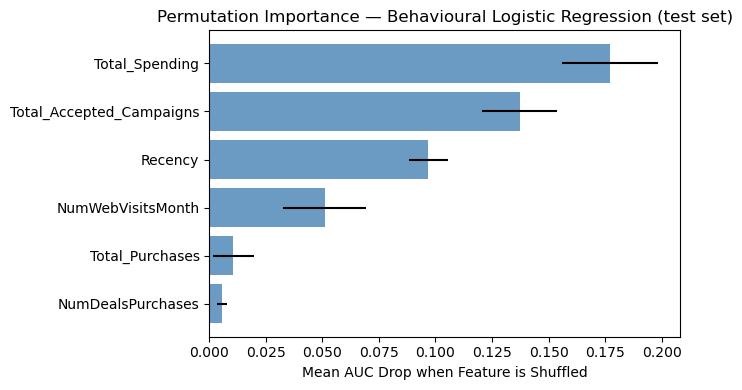

In [89]:
perm_result_behav = permutation_importance(
    behav_model, X_test_behav, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df_behav = pd.DataFrame({
    'Feature':         numerical_features_behav,
    'Importance_Mean': perm_result_behav.importances_mean,
    'Importance_Std':  perm_result_behav.importances_std,
}).sort_values('Importance_Mean', ascending=False)

print("Permutation Importance — Behavioural Model (test set):\n")
print(perm_df_behav.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
top_perm_behav = perm_df_behav.sort_values('Importance_Mean')
ax.barh(top_perm_behav['Feature'], top_perm_behav['Importance_Mean'],
        xerr=top_perm_behav['Importance_Std'], color='steelblue', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Behavioural Logistic Regression (test set)")
plt.tight_layout()
plt.show()

### 4.9 SHAP Values

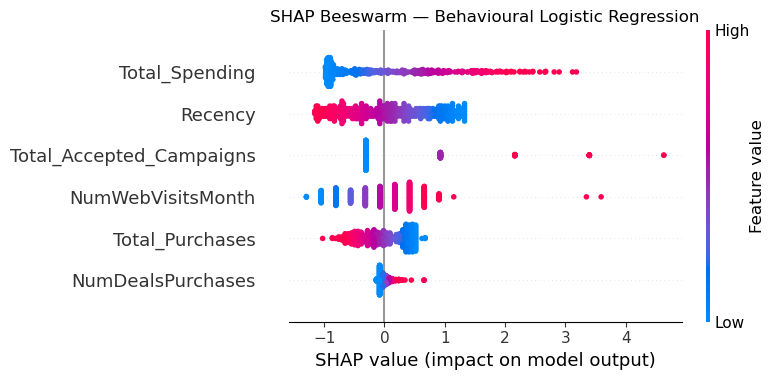

In [90]:
X_behav_test_t  = behav_model.named_steps['preprocessor'].transform(X_test_behav)
X_behav_train_t = behav_model.named_steps['preprocessor'].transform(X_train_behav)

explainer_behav   = shap.LinearExplainer(
    behav_model.named_steps['classifier'],
    X_behav_train_t,
    feature_perturbation='interventional'
)
shap_values_behav = explainer_behav.shap_values(X_behav_test_t)

shap.summary_plot(shap_values_behav, X_behav_test_t,
                  feature_names=numerical_features_behav, show=False)
plt.title("SHAP Beeswarm — Behavioural Logistic Regression")
plt.tight_layout()
plt.show()

### 4.10. Interpretation of Behavioral Model Results

The behavioural model has a **ROC-AUC** of 0.85, indicating good overall discriminative ability with only six engagement variables. At the tuned threshold of 0.19, the model accurately detects 38 out of 67 actual respondents (**recall** of 57% and **precision** of 44%), implying that almost two out of every five consumers classified as possible responders will convert, a significant improvement over the 15% baseline.

Among the positive drivers, `Total_Accepted_Campaigns` is the strongest predictor (OR = 2.31), reinforcing that prior engagement is the clearest signal of future receptiveness. `Total_Spending` follows closely (OR = 2.02), confirming that higher-value customers are significantly more likely to respond.

`Recency` has the largest negative coefficient (OR = 0.47), supporting the EDA's result that consumers who purchased more recently are significantly more likely to react (every extra day since the last purchase lowers the chance of responding). Additionally, `Total_Purchases` has a negative coefficient (OR = 0.76), alongside a positive Total_Spending, indicating that customers who spend more on each transaction, instead of buying more frequently, are the most profitable targets for this campaign.

Surprisingly, **NumWebVisitsMonth** has a positive coefficient (OR = 1.55), which appears to contradict the EDA result of a near-zero difference across groups. This is likely a suppressor effect: once spending and recency are controlled for, frequent web visitors who still spend are a positive signal. Finally, `NumDealsPurchases` has a modest positive effect (OR = 1.07).



## 5. Demographic Model - L1 Regularization 

The demographic model uses only customer profile and household composition 
variables. While the five numerical features are largely independent, the 
categorical variables `Education` and `Marital_Status` expand to approximately 
14 columns after one-hot encoding, and several categories (particularly `Widow` 
and `Other`) contain very few observations.

Without regularisation, coefficients on sparse categories can become inflated 
and unstable, driven by small sample artefacts rather than genuine signal. 
The regularisation strategy is selected empirically in Section 5.2 — L1 is 
chosen over L2 and Elastic Net because zeroing out coefficients on uninformative 
sparse categories is preferable to merely shrinking them, reducing the risk of 
low-frequency categories driving predictions.

In [96]:
# Helper: fresh preprocessor for demographic model
def make_preprocessor_demo():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features_demo),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features_demo)
    ])

### 5.1. Baseline Model


In [97]:
# Baseline: sklearn defaults (L2, C=1.0) with class_weight='balanced'
demo_model_base = Pipeline(steps=[
    ('preprocessor', make_preprocessor_demo()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

demo_model_base.fit(X_train_demo, y_train)

y_prob_demo_base = demo_model_base.predict_proba(X_test_demo)[:, 1]
y_pred_demo_base = demo_model_base.predict(X_test_demo)

print(f"Default LR — ROC-AUC : {roc_auc_score(y_test, y_prob_demo_base):.4f}")
print(f"Default LR — Recall  : {recall_score(y_test, y_pred_demo_base):.4f}")
print(f"Default LR — F1      : {f1_score(y_test, y_pred_demo_base):.4f}")

Default LR — ROC-AUC : 0.7667
Default LR — Recall  : 0.7015
Default LR — F1      : 0.4069


### 5.2 Regularisation Strategy Selection


The same four penalty options are compared at `C=1.0` using 5-fold stratified 
cross-validation on the demographic feature set.

In [98]:
reg_results_demo = []
for cfg in reg_configs:
    lr_kwargs = dict(
        penalty=cfg['penalty'],
        solver=cfg['solver'],
        C=cfg['C'],
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    if cfg['l1_ratio'] is not None:
        lr_kwargs['l1_ratio'] = cfg['l1_ratio']

    pipe = Pipeline(steps=[
        ('preprocessor', make_preprocessor_demo()),
        ('classifier',   LogisticRegression(**lr_kwargs))
    ])

    scores = cross_val_score(
        pipe, X_train_demo, y_train,
        cv=cv_strategy, scoring='roc_auc'
    )
    reg_results_demo.append({
        'Regularisation': cfg['name'],
        'CV AUC Mean':    round(scores.mean(), 4),
        'CV AUC Std':     round(scores.std(), 4),
    })

reg_df_demo = pd.DataFrame(reg_results_demo).set_index('Regularisation')
print("Regularisation Strategy Comparison — Demographic Model (C=1.0, untuned)\n")
print(reg_df_demo.to_string())

Regularisation Strategy Comparison — Demographic Model (C=1.0, untuned)

                   CV AUC Mean  CV AUC Std
Regularisation                            
No Regularisation       0.7449      0.0242
L2 (Ridge)              0.7517      0.0242
L1 (Lasso)              0.7530      0.0247
Elastic Net             0.7524      0.0245


### 5.3 Hyperparameter Tuning (C)


The penalty type is fixed to the winner from Section 5.2. A single **GridSearchCV** over `C` is sufficient here (with only one parameter to tune, the three-stage approach used in the full model is not necessary).

In [99]:
# Tune C — penalty type fixed from regularisation comparison above
param_grid_demo = {
    'classifier__C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

grid_search_demo = GridSearchCV(
    Pipeline(steps=[
        ('preprocessor', make_preprocessor_demo()),
        ('classifier', LogisticRegression(
            penalty='l1',    
            solver='saga',  
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_grid = param_grid_demo,
    scoring    = 'roc_auc',
    cv         = cv_strategy,
    n_jobs     = 1,
    verbose    = 1
)

grid_search_demo.fit(X_train_demo, y_train)

print(f"Best C      : {grid_search_demo.best_params_['classifier__C']}")
print(f"Best CV AUC : {grid_search_demo.best_score_:.4f}")

# Rebuild demo_model explicitly
best_C_demo = grid_search_demo.best_params_['classifier__C']

demo_model = Pipeline(steps=[
    ('preprocessor', make_preprocessor_demo()),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='saga',
        C=best_C_demo,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])
demo_model.fit(X_train_demo, y_train)
print("demo_model rebuilt with optimised parameters.")

# CV score + improvement over baseline
cv_scores_demo = cross_val_score(
    demo_model, X_train_demo, y_train,
    cv=cv_strategy, scoring='roc_auc'
)

baseline_cv_demo = cross_val_score(
    demo_model_base, X_train_demo, y_train,
    cv=cv_strategy, scoring='roc_auc'
).mean()

print(f"\nCV ROC-AUC      : {cv_scores_demo.mean():.4f} ± {cv_scores_demo.std():.4f}")
print(f"Baseline CV AUC : {baseline_cv_demo:.4f}")
print(f"Tuned CV AUC    : {cv_scores_demo.mean():.4f}  "
      f"(Δ = {cv_scores_demo.mean() - baseline_cv_demo:+.4f})")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best C      : 0.1
Best CV AUC : 0.7545
demo_model rebuilt with optimised parameters.

CV ROC-AUC      : 0.7545 ± 0.0296
Baseline CV AUC : 0.7517
Tuned CV AUC    : 0.7545  (Δ = +0.0029)


### 5.4. Threshold Tuning

In [100]:
threshold_demo = find_best_threshold_oof(demo_model, X_train_demo, y_train)

Optimal threshold (F1): 0.5837
Best OOF F1:            0.4218


### 5.5. Model Evaluation


In [101]:
y_prob_demo = demo_model.predict_proba(X_test_demo)[:, 1]
y_pred_demo = (y_prob_demo >= threshold_demo).astype(int)

## Metrics
accuracy_demo = accuracy_score(y_test, y_pred_demo)
precision_demo = precision_score(y_test, y_pred_demo)
recall_demo = recall_score(y_test, y_pred_demo)
f1_demo = f1_score(y_test, y_pred_demo)
auc_demo = roc_auc_score(y_test, y_prob_demo)

print(f"\nROC-AUC   : {roc_auc_score(y_test, y_prob_demo):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_demo):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_demo):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_demo):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_demo):.4f}")


ROC-AUC   : 0.7594
Precision : 0.3362
Recall    : 0.5821
F1        : 0.4262
Accuracy  : 0.7656


### 5.6. Confusion Matrix


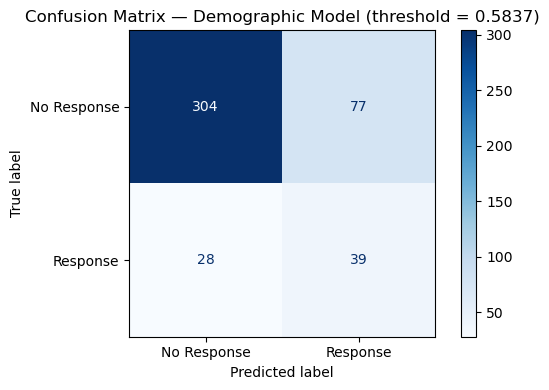

              precision    recall  f1-score   support

 No Response       0.92      0.80      0.85       381
    Response       0.34      0.58      0.43        67

    accuracy                           0.77       448
   macro avg       0.63      0.69      0.64       448
weighted avg       0.83      0.77      0.79       448



In [102]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_demo,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — Demographic Model (threshold = {threshold_demo:.4f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_demo,
                             target_names=['No Response', 'Response']))

### 5.7 Precision-Recall Curve

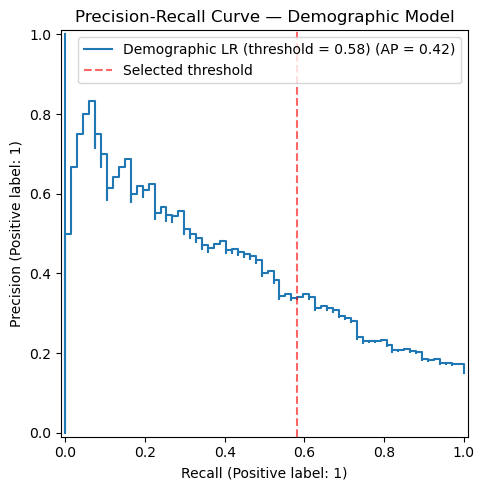

In [103]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_demo,
    name=f"Demographic LR (threshold = {threshold_demo:.2f})",
    ax=ax
)
ax.axvline(recall_score(y_test, y_pred_demo), color='red',
           linestyle='--', alpha=0.6, label='Selected threshold')
ax.set_title("Precision-Recall Curve — Demographic Model")
ax.legend()
plt.tight_layout()
plt.show()

### 5.8. ROC Curve


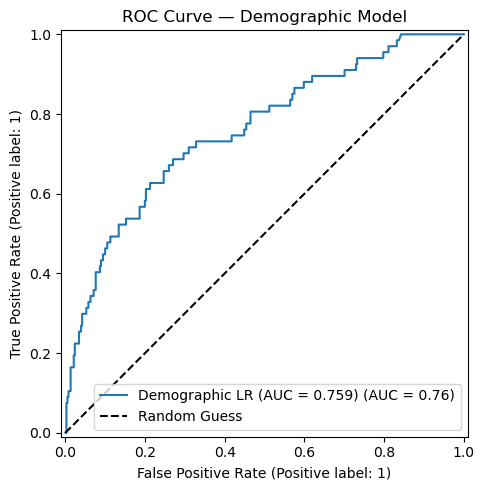

In [104]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_demo,
    name=f"Demographic LR (AUC = {roc_auc_score(y_test, y_prob_demo):.3f})",
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title("ROC Curve — Demographic Model")
ax.legend()
plt.tight_layout()
plt.show()

### 5.9. Feature Importance (Coefficients)


In [107]:
ohe_demo       = demo_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names_demo = ohe_demo.get_feature_names_out(categorical_features_demo).tolist()
all_names_demo = numerical_features_demo + cat_names_demo

coefs_demo = demo_model.named_steps['classifier'].coef_[0]

coef_df_demo = pd.DataFrame({
    'Feature':     all_names_demo,
    'Coefficient': coefs_demo,
    'Odds Ratio':  np.exp(coefs_demo)
}).sort_values('Coefficient', ascending=False)

coef_df_demo.round(4)

,Feature,Coefficient,Odds Ratio
2,Customer_Tenure,0.6525,1.9204
8,Education_PhD,0.4413,1.5548
1,Income,0.4016,1.4942
3,Kidhome,0.0401,1.0409
0,Age,0.0000,1.0000
5,Education_Basic,0.0000,1.0000
6,Education_Graduation,0.0000,1.0000
7,Education_Master,0.0000,1.0000
10,Marital_Status_Other,0.0000,1.0000
11,Marital_Status_Single,0.0000,1.0000


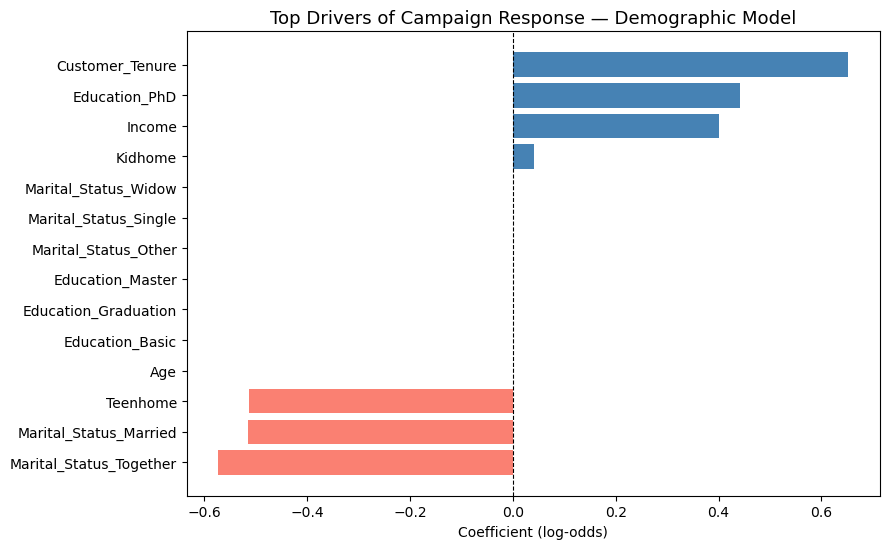

In [108]:
coef_df_demo_sorted = coef_df_demo.sort_values('Coefficient', ascending=True)
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_demo_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_demo_sorted) * 0.4)))
ax.barh(coef_df_demo_sorted['Feature'], coef_df_demo_sorted['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Demographic Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

### 5.10. Permutation Importance


Permutation Importance — Demographic Model (test set):

        Feature  Importance_Mean  Importance_Std
Customer_Tenure         0.071450        0.020255
         Income         0.068132        0.011926
       Teenhome         0.048098        0.022947
 Marital_Status         0.034154        0.008218
      Education         0.014643        0.005797
        Kidhome         0.000411        0.001253
            Age         0.000000        0.000000


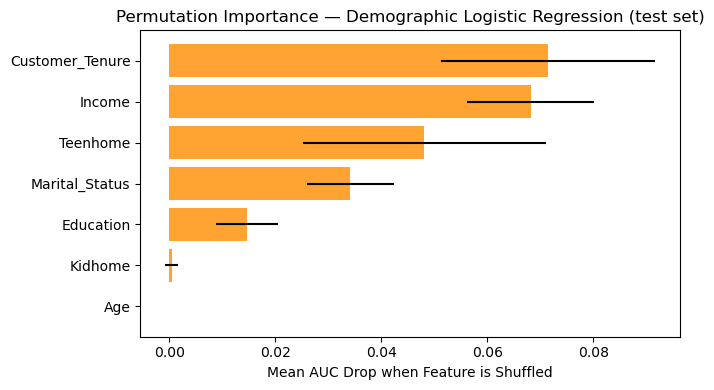

In [109]:
raw_feature_names_demo = numerical_features_demo + categorical_features_demo

perm_result_demo = permutation_importance(
    demo_model, X_test_demo, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df_demo = pd.DataFrame({
    'Feature':         raw_feature_names_demo,
    'Importance_Mean': perm_result_demo.importances_mean,
    'Importance_Std':  perm_result_demo.importances_std,
}).sort_values('Importance_Mean', ascending=False)

print("Permutation Importance — Demographic Model (test set):\n")
print(perm_df_demo.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
top_perm_demo = perm_df_demo.sort_values('Importance_Mean')
ax.barh(top_perm_demo['Feature'], top_perm_demo['Importance_Mean'],
        xerr=top_perm_demo['Importance_Std'], color='darkorange', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Demographic Logistic Regression (test set)")
plt.tight_layout()
plt.show()

### 5.11. SHAP Values

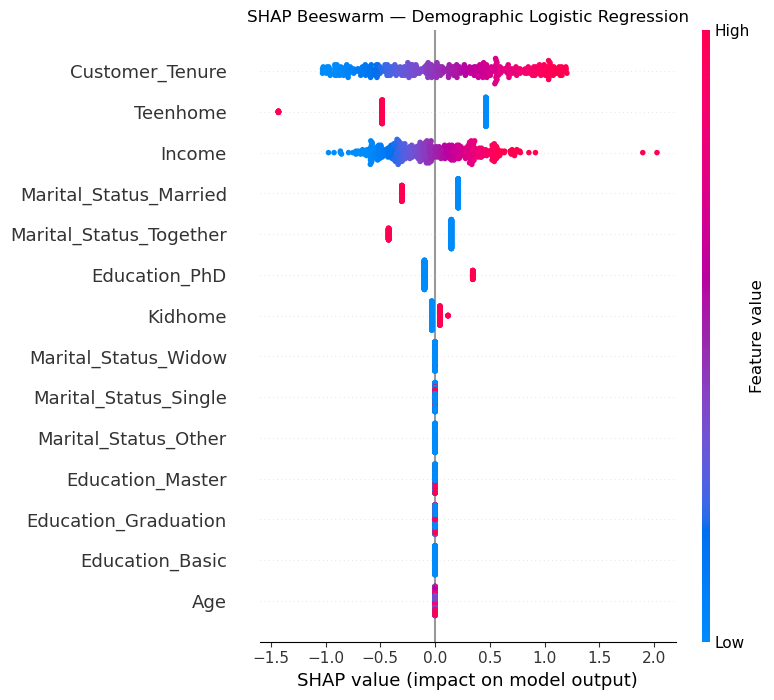

In [110]:
X_demo_test_t  = demo_model.named_steps['preprocessor'].transform(X_test_demo)
X_demo_train_t = demo_model.named_steps['preprocessor'].transform(X_train_demo)

explainer_demo   = shap.LinearExplainer(
    demo_model.named_steps['classifier'],
    X_demo_train_t,
    feature_perturbation='interventional'
)
shap_values_demo = explainer_demo.shap_values(X_demo_test_t)

shap.summary_plot(shap_values_demo, X_demo_test_t,
                  feature_names=all_names_demo, show=False)
plt.title("SHAP Beeswarm — Demographic Logistic Regression")
plt.tight_layout()
plt.show()

### 5.12. Interpretation of Demographic and Household Model Results

The demographic model achieves a **ROC-AUC** of 0.77, indicating moderate discriminative ability, consistent with the EDA finding that demographic variables are inherently weaker predictors of campaign response than behavioural ones. The F1-optimal threshold was found at 0.19 through out-of-fold cross-validation — considerably lower than the default 0.50 — reflecting the model's limited confidence in assigning high probabilities to the minority class.

At this threshold, the model correctly identifies 42 out of 67 actual responders, achieving a **recall** of 63% on the positive class, the highest recall of the three models. **Precision** stands at 32%, meaning that out of 130 customers flagged as likely responders (42 true positives + 88 false positives), roughly 1 in 3 would actually convert. In practical terms, the company would need to contact approximately 3 customers to reach 1 true responder, still a meaningful improvement over untargeted outreach where the baseline conversion rate is only 15%.

The coefficient table confirms the demographic profile of a likely responder: `Customer_Tenure` (OR = 2.03) and `Education_PhD` (OR = 1.93) are the strongest positive predictors, followed by `Income` (OR = 1.52) and `Marital_Status_Widow` (OR = 1.47). `Marital_Status_Other` (OR = 1.36) and `Education_Master` (OR = 1.27) also contribute positively.

On the negative side, `Marital_Status_Together` (OR = 0.45) and `Marital_Status_Married` (OR = 0.49) are the strongest deterrents, followed by `Education_Basic` (OR = 0.46) and `Teenhome` (OR = 0.57), suggesting that customers in shared households with lower education and teenagers at home are significantly less receptive. 

`Age` and `Marital_Status_Single` carry near-zero coefficients, confirming they add no meaningful predictive signal once the remaining variables are accounted for.

Overall, the demographic model is best understood as a profiling tool rather than a precision targeting instrument. Its high recall makes it useful for broad identification of likely responders, but its low precision means it generates a substantial number of wasted contacts, making it most appropriate as a fallback when transaction history is unavailable.

## 6. Summary of Results

### 6.1. Metrics Table

In [111]:
results = {
    'Model': ['Full', 'Behavioural', 'Demographic'],
    'Threshold': [threshold_full, threshold_behav, threshold_demo],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_full),
        roc_auc_score(y_test, y_prob_behav),
        roc_auc_score(y_test, y_prob_demo)
    ],
    'Precision (1)': [
        precision_score(y_test, y_pred_full, zero_division=0),
        precision_score(y_test, y_pred_behav, zero_division=0),
        precision_score(y_test, y_pred_demo, zero_division=0)
    ],
    'Recall (1)': [
        recall_score(y_test, y_pred_full, zero_division=0),
        recall_score(y_test, y_pred_behav, zero_division=0),
        recall_score(y_test, y_pred_demo, zero_division=0)
    ],
    'F1 (1)': [
        f1_score(y_test, y_pred_full, zero_division=0),
        f1_score(y_test, y_pred_behav, zero_division=0),
        f1_score(y_test, y_pred_demo, zero_division=0)
    ],
}

results_df = pd.DataFrame(results).set_index('Model').round(3)

def highlight_best(s):
    is_best = s == s.max()
    return ['background-color: #a8d5a2; color: #155724; font-weight: bold'
            if v else '' for v in is_best]

results_df.style.apply(highlight_best, axis=0).format("{:.3f}")


,Threshold,ROC-AUC,Precision (1),Recall (1),F1 (1)
Model,,,,,
Full,0.628,0.879,0.511,0.701,0.591
Behavioural,0.615,0.859,0.500,0.522,0.511
Demographic,0.584,0.759,0.336,0.582,0.426


### 6.2. ROC Curves

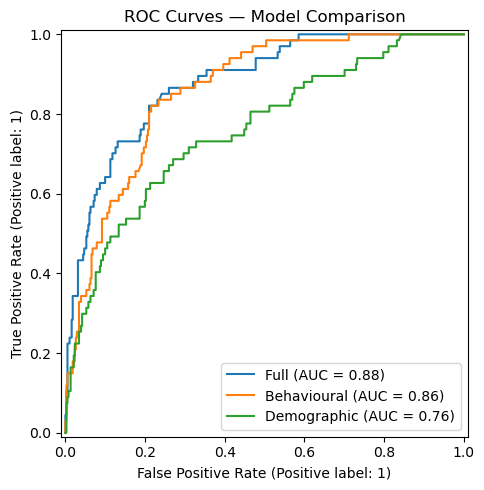

In [112]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_full, name="Full", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_behav, name="Behavioural", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_demo, name="Demographic", ax=ax)
ax.set_title("ROC Curves — Model Comparison")
plt.tight_layout()
plt.show()

### 6.3. Model Comparison

### 6.4. Recommended Model

## 7. Business Recommendations